In [15]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [3]:


# Connect to the database (or create it)
conn = sqlite3.connect('sales_data.db')
cursor = conn.cursor()


In [5]:

# Create the sales table if it doesn't exist
cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
''')

In [7]:


# Clear existing data to avoid duplicates on re-run
cursor.execute('DELETE FROM sales')

# Insert sample sales data
sample_data = [
    ('Product A', 10, 15.0),
    ('Product B', 5, 25.0),
    ('Product A', 3, 15.0),
    ('Product C', 8, 12.5),
    ('Product B', 7, 25.0),
    ('Product C', 4, 12.5)
]

cursor.executemany('INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)', sample_data)



In [9]:

# Commit and close the connection
conn.commit()
conn.close()


In [13]:


# Connect to the database
conn = sqlite3.connect("sales_data.db")

# SQL query to get total quantity and revenue per product
query = """
SELECT product, 
       SUM(quantity) AS total_qty, 
       SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

# Run the query and load results into pandas DataFrame
df = pd.read_sql_query(query, conn)

# Close connection
conn.close()

# Display results
print(df)


     product  total_qty  revenue
0  Product A         13    195.0
1  Product B         12    300.0
2  Product C         12    150.0


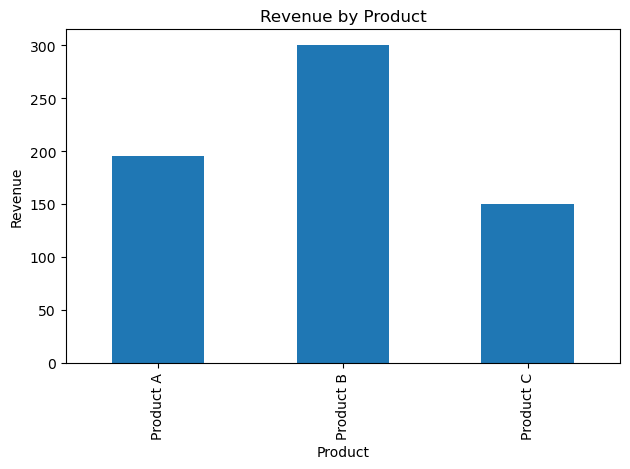

In [17]:
# Plot a bar chart of revenue per product
df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.title('Revenue by Product')
plt.ylabel('Revenue')
plt.xlabel('Product')
plt.tight_layout()

# Show the plot
plt.show()

In [19]:

#Optional: Save the plot
plt.savefig("sales_chart.png")

<Figure size 640x480 with 0 Axes>